# Supplier Risk & Performance Scoring

A sector-independent (non-defense) supply chain analytics project. This notebook walks through the full v2 pipeline built in `src/`:

1. A synthetic, intentionally messy supplier dataset (generated with Faker for a Turkish SME/large-industry context), including real Turkish business-rule fields (VKN tax ID, KOSGEB-aligned company size)
2. A profile-driven, source-agnostic cleaning engine (`src/cleaning/`) — new ERP source = new YAML profile, not new code
3. **Two independent risk axes**, deliberately not blended into one number:
   - `risk_score` — operational/performance risk (delivery, price volatility, concentration, quality)
   - `financial_risk_score` — financial/solvency risk (overdue debt, leverage, payment defaults), conceptually inspired by a Findeks Ticari Risk Raporu
4. Portfolio-level concentration risk via the **Herfindahl-Hirschman Index (HHI)**, a real economics/antitrust metric
5. Turkish practitioner-grounded due-diligence red flags (export documentation, upfront-payment demands, site visits)
6. Visual exploration of all of the above, and a sensitivity check on the scoring weights

The scored output (`reports/supplier_risk_scores.csv`) is what feeds the Power BI dashboard.

In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")  # lets us import the scoring functions, not just the CSV outputs

sns.set_theme(style="whitegrid")
RISK_COLORS = {"Low": "#2ca02c", "Medium": "#ff9800", "High": "#d62728"}
RISK_ORDER = ["Low", "Medium", "High"]
pd.set_option("display.max_columns", None)

## 1. The raw data problem

Real supplier exports are rarely clean. To make that concrete (and to have something genuine to clean), `src/generate_suppliers.py` builds a synthetic dataset with the same problems a real Excel export from multiple ERP systems tends to have: mixed date formats, mixed decimal separators, inconsistent category labels, missing cells, and casing noise.

In [2]:
raw_df = pd.read_csv("../data/raw/suppliers_raw.csv", encoding="utf-8-sig")
print(f"{len(raw_df)} suppliers, {raw_df.shape[1]} columns")
raw_df.head()

85 suppliers, 28 columns


,supplier_id,company_name,sector,city,company_size,founded_year,employee_count,vkn,supplier_annual_revenue_tl,annual_purchase_volume_tl,total_orders_last_year,late_orders_last_year,price_q1,price_q2,price_q3,price_q4,units_shipped_last_year,units_returned_last_year,contract_start_date,last_audit_date,payment_terms_days,iso_certified,overdue_debt_ratio,debt_to_revenue_ratio,payment_default_last_3y,has_export_documentation,requires_full_upfront_payment,site_visit_verified
0,SUP079,Ülker Şafak Plastik Tic.,plastik ve kauçuk,gaziantep,KÜÇÜK,1986.0,35.0,5039106517,"18.184.748,00","2.587.372,82",23,1.0,229.93,238.15,242.03,246.44,12245,1618.0,19/04/2018,NaN,30.0,hayır,"0,26","0,27",HAYIR,1,NaN,NaN
1,SUP001,korutürk tekstil san. tic. ltd. şti.,Tekstil,Manisa,orta,1976.0,193.0,4863794023,225584135.67,"5.492.821,36",134,38.0,"322,41","313,40","317,95","281,45",46048,6596.0,02.08.2018,2024-09-29,90.0,true,"0,05","0,41",hayır,Yes,false,Hayır
2,SUP069,Yildirim Plastik San. ve Tic. A.S.,Plastik ve Kaucuk,denizli,orta,1987.0,142.0,9416878495,107359665.35,NaN,126,6.0,"363,81",374.61,"390,87","444,82",71680,8646.0,12/10/2017,30-05-25,30.0,EVET,NaN,0.07,hayır,true,hayır,true
3,SUP023,Şener Karadeniz Kauçuk Ltd. Şti.,PLASTIK VE KAUÇUK,Aydın,Küçük,2016.0,16.0,7572628493,98545991.64,"19.924.006,54",48,17.0,69.37,66.79,"63,84","66,06",13697,1421.0,2021-06-03,2025-08-28,NaN,false,0.18,0.70,false,1,Hayır,Yes
4,SUP013,Kısakürek Makine Tic.,makine i̇malat,Bursa,MİKRO,2021.0,2.0,6869232261,4007551.85,"864.659,48",9,1.0,16.61,"18,48",18.45,"17,42",4569,135.0,2018-06-07,21-11-24,30.0,HAYIR,"0,14","0,58",HAYIR,Hayır,0,evet


In [3]:
print("Raw 'company_size' labels actually found in the data (should be one value, not four):")
print(sorted(raw_df["company_size"].dropna().unique()))
print()

print("Raw 'contract_start_date' values (sample) — four different date formats mixed together:")
print(raw_df["contract_start_date"].dropna().sample(6, random_state=1).tolist())
print()

print("Raw 'price_q1' values (sample) — Turkish comma-decimal and plain dot-decimal mixed:")
print(raw_df["price_q1"].dropna().sample(6, random_state=2).tolist())
print()

print("Missing values per column:")
print(raw_df.isna().sum())

Raw 'company_size' labels actually found in the data (should be one value, not four):
['KÜÇÜK', 'Küçük', 'Large', 'Medium', 'Micro', 'MİKRO', 'ORTA', 'Orta', 'Small', 'büyük', 'küçük', 'mikro', 'orta']

Raw 'contract_start_date' values (sample) — four different date formats mixed together:
['20-11-20', '15-05-21', '25-09-24', '17/04/2019', '04.03.2018', '12/01/2018']

Raw 'price_q1' values (sample) — Turkish comma-decimal and plain dot-decimal mixed:
['103,20', '595,90', '145.01', '280.99', '56,99', '318.13']

Missing values per column:
supplier_id                       0
company_name                      0
sector                            0
city                              2
company_size                      0
founded_year                      8
employee_count                    5
vkn                               0
supplier_annual_revenue_tl        6
annual_purchase_volume_tl         4
total_orders_last_year            0
late_orders_last_year             3
price_q1                 

## 2. Cleaning approach

`src/clean_suppliers.py` no longer hardcodes cleaning rules for one source — it delegates to a generic engine (`src/cleaning/engine.py`) driven by a declarative YAML **profile** (`config/erp_profiles/synthetic_generator.yaml` for this dataset). The engine itself has zero source-specific knowledge; every rule below lives in the profile, not in code:

- **Numbers:** a small parser detects whether a value uses Turkish-style (`1.234,56`) or plain (`1234.56`) formatting and converts both to a real float.
- **Dates:** each value is tried against the known raw formats (listed in the profile) until one matches.
- **Category columns** (`company_size`, `iso_certified`, `payment_default_last_3y`, and the three due-diligence red-flag columns): matched against an explicit dictionary of every known raw variant (e.g. `küçük`/`KÜÇÜK`/`Small` all map to `Small`) — safer than case-insensitive string matching, which breaks on Turkish ı/İ (see below).
- **`sector` / `city`:** these come from a small closed list, so a messy value can be matched back to its correct canonical Turkish spelling even if it lost its diacritics or has odd casing.
- **`company_name`:** whitespace and casing are normalized, but a diacritic that was already lost upstream (e.g. `"Demir Celik"` instead of `"Demir Çelik"`) is **not** guessed back — the letter is ambiguous once lost, so guessing would just be a different kind of wrong data.
- **`vkn` (Vergi Kimlik Numarası):** Turkey's real 10-digit tax-ID checksum algorithm is applied and any failure is flagged in `vkn_valid`, not silently corrected — this is a bespoke business-rule check layered on top of the generic engine, not part of the reusable profile system.

One genuine bug surfaced while building this: Python's default `str.lower()` is not Turkish-locale-aware. Lowercasing `'İ'` produces `'i'` followed by an invisible combining dot character (U+0307) instead of a plain `'i'` — a well-known Unicode/Turkish edge case. Left uncaught, this silently broke category matching. The fix (in `src/cleaning/text_utils.py`) strips stray combining marks before comparing strings.

Because the engine is profile-driven, adapting this pipeline to a real company's SAP or Logo/Netsis export means writing a new YAML profile (see `config/erp_profiles/sap_export_example.yaml`), not touching this code — and an AI-assisted drafting tool (`src/ai_draft_profile.py`) can propose a first-pass profile from a sample export, which is then schema-validated before anyone trusts it.

In [4]:
clean_df = pd.read_csv("../data/processed/suppliers_clean.csv", encoding="utf-8-sig")

print("Standardized 'company_size' values:", sorted(clean_df["company_size"].dropna().unique()))
print("Standardized 'iso_certified' values:", clean_df["iso_certified"].dropna().unique().tolist())
print()
clean_df.head()

Standardized 'company_size' values: ['Large', 'Medium', 'Micro', 'Small']
Standardized 'iso_certified' values: [False, True]



,supplier_id,company_name,sector,city,company_size,founded_year,employee_count,vkn,supplier_annual_revenue_tl,annual_purchase_volume_tl,total_orders_last_year,late_orders_last_year,price_q1,price_q2,price_q3,price_q4,units_shipped_last_year,units_returned_last_year,contract_start_date,last_audit_date,payment_terms_days,iso_certified,overdue_debt_ratio,debt_to_revenue_ratio,payment_default_last_3y,has_export_documentation,requires_full_upfront_payment,site_visit_verified,vkn_valid
0,SUP079,Ülker Şafak Plastik Tic.,Plastik ve Kauçuk,Gaziantep,Small,1986.0,35.0,5039106517,1.818475e+07,2587372.82,23,1.0,229.93,238.15,242.03,246.44,12245,1618.0,2018-04-19,NaN,30.0,False,0.26,0.27,False,True,NaN,NaN,True
1,SUP001,Korutürk Tekstil San. Tic. Ltd. Şti.,Tekstil,Manisa,Medium,1976.0,193.0,4863794023,2.255841e+08,5492821.36,134,38.0,322.41,313.40,317.95,281.45,46048,6596.0,2018-08-02,2024-09-29,90.0,True,0.05,0.41,False,True,False,False,True
2,SUP069,Yildirim Plastik San. ve Tic. A.Ş.,Plastik ve Kauçuk,Denizli,Medium,1987.0,142.0,9416878495,1.073597e+08,NaN,126,6.0,363.81,374.61,390.87,444.82,71680,8646.0,2017-10-12,2025-05-30,30.0,True,NaN,0.07,False,True,False,True,True
3,SUP023,Şener Karadeniz Kauçuk Ltd. Şti.,Plastik ve Kauçuk,Aydın,Small,2016.0,16.0,7572628493,9.854599e+07,19924006.54,48,17.0,69.37,66.79,63.84,66.06,13697,1421.0,2021-06-03,2025-08-28,NaN,False,0.18,0.70,False,True,False,True,True
4,SUP013,Kısakürek Makine Tic.,Makine İmalat,Bursa,Micro,2021.0,2.0,6869232261,4.007552e+06,864659.48,9,1.0,16.61,18.48,18.45,17.42,4569,135.0,2018-06-07,2024-11-21,30.0,False,0.14,0.58,False,False,False,True,True


## 3. Risk scoring methodology — operational axis

This is the first of two independent risk axes computed by `src/score_suppliers.py` (see Section 5 for the second, `financial_risk_score`). Four criteria, each a standard building block of a real-world supplier scorecard:

| Criterion | What it measures | Default weight |
|---|---|---|
| `delivery_delay_rate` | Share of orders delivered late | 35% |
| `price_volatility` | Coefficient of variation of quarterly unit price | 25% |
| `supplier_dependency_ratio` | This supplier's share of total purchase volume (concentration risk) | 25% |
| `quality_return_rate` | Share of shipped units returned | 15% |

Weights are **not hardcoded** — they live in `config/scoring_weights.yaml` so anyone reusing this project can adapt them to their own priorities (the file is validated to always sum to 100%).

**Why min-max normalization?** The four raw metrics live on completely different scales (a 0-1 rate vs. a share of TL millions). Each metric is rescaled so the riskiest supplier on *that specific metric* scores 100 and the safest scores 0 — only then can they be combined with weights into one number.

**Why percentile-based Low/Medium/High cutoffs, not fixed score cutoffs?** A supplier is rarely the worst on all four metrics simultaneously, so combined scores cluster toward the middle of the range. A first attempt with a fixed cutoff (score > 66 = High) produced **zero** High-risk suppliers. Labeling the riskiest ~15% and safest ~60% of the *current* supplier population (percentile-based) always produces a meaningful spread, regardless of the underlying score range.

**v2 change — concentration risk is now HHI-inspired:** `supplier_dependency_ratio_score` normalizes on each supplier's *squared* share of total volume, not the linear share, so a supplier at 20% of spend is penalized disproportionately more than four suppliers at 5% each — the same logic behind the real Herfindahl-Hirschman Index used in antitrust review (see Section 5). The displayed `supplier_dependency_ratio` column itself stays the plain, human-readable share.

In [5]:
scores_df = pd.read_csv("../reports/supplier_risk_scores.csv", encoding="utf-8-sig")
scores_df.sort_values("risk_score", ascending=False).head(10)

,supplier_id,company_name,sector,city,company_size,delivery_delay_rate,price_volatility,supplier_dependency_ratio,quality_return_rate,delivery_delay_rate_score,price_volatility_score,supplier_dependency_ratio_score,quality_return_rate_score,risk_score,risk_level,has_estimated_inputs,financial_risk_score,financial_risk_level,financial_risk_has_estimated_inputs
0,SUP066,Hançer Gülen Mobilya Tic.,Mobilya,NaN,Micro,0.5556,0.0521,0.0007,0.7410,100.0,40.7,0.0,100.0,60.2,High,True,29.9,Medium,False
1,SUP063,Aksu San. ve Tic. A.Ş.,Otomotiv Yan Sanayi,Trabzon,Large,0.3333,0.0385,0.1405,0.0672,60.0,29.9,100.0,8.7,54.8,High,False,17.5,Low,False
2,SUP021,Arslan Çorlu Kauçuk Tic.,Plastik ve Kauçuk,Çorum,Small,0.5455,0.0605,0.0012,0.0709,98.2,47.4,0.0,9.3,47.6,High,False,80.8,High,False
3,SUP018,Şener Mansız Otomotiv Tic.,Otomotiv Yan Sanayi,Denizli,Micro,0.3793,0.0784,0.0009,0.1502,68.3,61.5,0.0,20.0,42.3,High,False,49.1,High,False
4,SUP006,Yıldırım Otomotiv Ltd. Şti.,Otomotiv Yan Sanayi,Kocaeli,Small,0.5455,0.0135,0.0029,0.2011,98.2,10.1,0.0,26.9,40.9,High,False,33.4,Medium,False
5,SUP062,Ülker Mobilya Tic.,Mobilya,Van,Micro,0.5000,0.0317,0.0001,0.1315,90.0,24.5,0.0,17.5,40.2,High,False,27.5,Medium,False
6,SUP022,Sakarya Kisakürek İplik Ltd. Şti.,Tekstil,Manisa,Micro,0.4167,0.0644,0.0002,0.0289,75.0,50.5,0.0,3.6,39.4,High,False,26.8,Low,False
7,SUP040,Çorlu İnönü Lojistik San. ve Tic. A.Ş.,Lojistik,Denizli,Medium,0.3827,0.0726,0.0084,0.0350,68.9,56.9,0.4,4.4,39.1,High,False,26.5,Low,False
8,SUP032,Çamurcuoğlu Ambalaj Ltd. Şti.,Ambalaj,İstanbul,Small,0.3621,0.0764,0.0059,0.0416,65.2,59.9,0.2,5.3,38.6,High,False,23.2,Low,False
9,SUP012,Şama İçecek Tic.,Gıda ve İçecek,İzmir,Micro,0.4615,0.0262,0.0003,0.2067,83.1,20.1,0.0,27.6,38.3,High,False,23.8,Low,True


## 4. Visual exploration

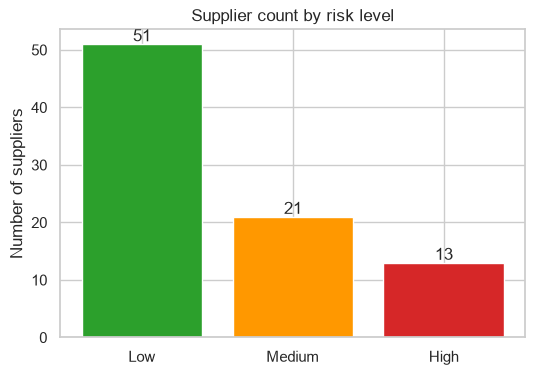

In [6]:
counts = scores_df["risk_level"].value_counts().reindex(RISK_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=[RISK_COLORS[level] for level in RISK_ORDER])
ax.set_title("Supplier count by risk level")
ax.set_ylabel("Number of suppliers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.show()

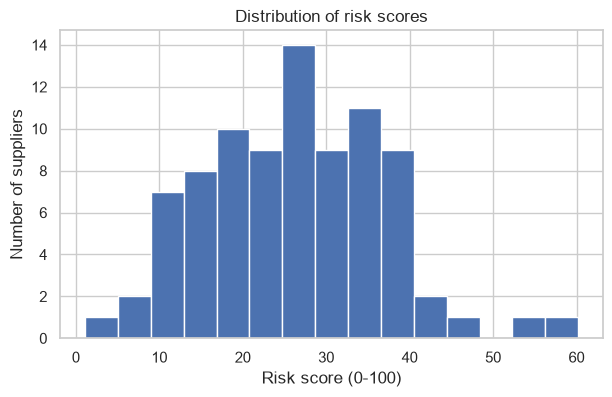

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_df["risk_score"], bins=15, color="#4c72b0", edgecolor="white")
ax.set_title("Distribution of risk scores")
ax.set_xlabel("Risk score (0-100)")
ax.set_ylabel("Number of suppliers")
plt.show()

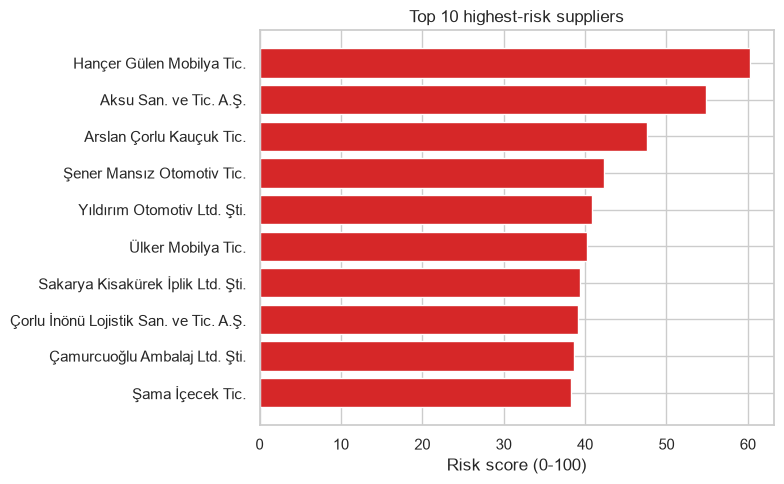

In [8]:
top10 = scores_df.sort_values("risk_score", ascending=False).head(10).iloc[::-1]
colors = [RISK_COLORS[level] for level in top10["risk_level"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["company_name"], top10["risk_score"], color=colors)
ax.set_title("Top 10 highest-risk suppliers")
ax.set_xlabel("Risk score (0-100)")
plt.tight_layout()
plt.show()

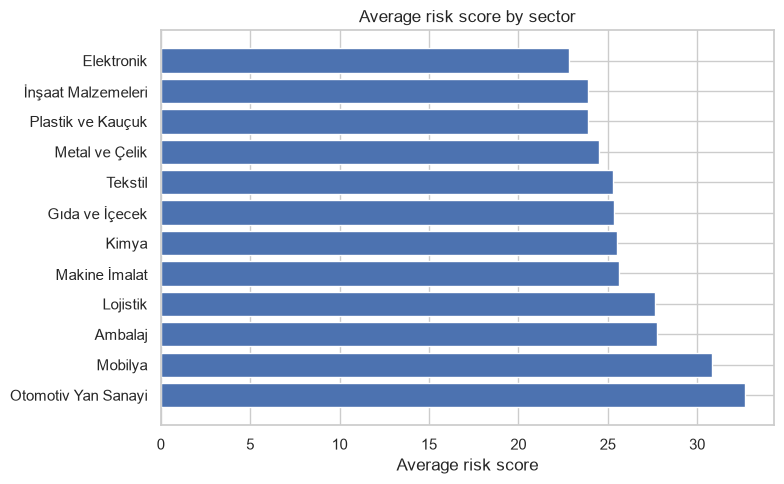

In [9]:
sector_avg = scores_df.groupby("sector")["risk_score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sector_avg.index, sector_avg.values, color="#4c72b0")
ax.set_title("Average risk score by sector")
ax.set_xlabel("Average risk score")
plt.tight_layout()
plt.show()

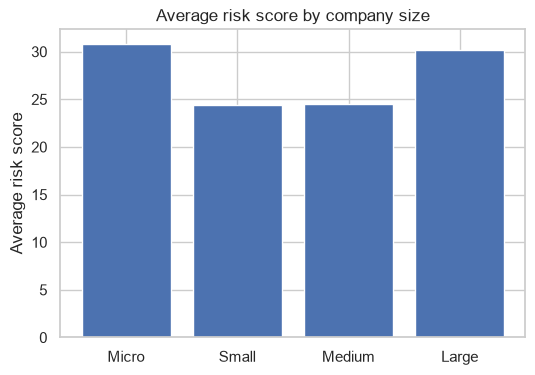

In [10]:
size_order = ["Micro", "Small", "Medium", "Large"]
size_avg = scores_df.groupby("company_size")["risk_score"].mean().reindex(size_order)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(size_avg.index, size_avg.values, color="#4c72b0")
ax.set_title("Average risk score by company size")
ax.set_ylabel("Average risk score")
plt.show()

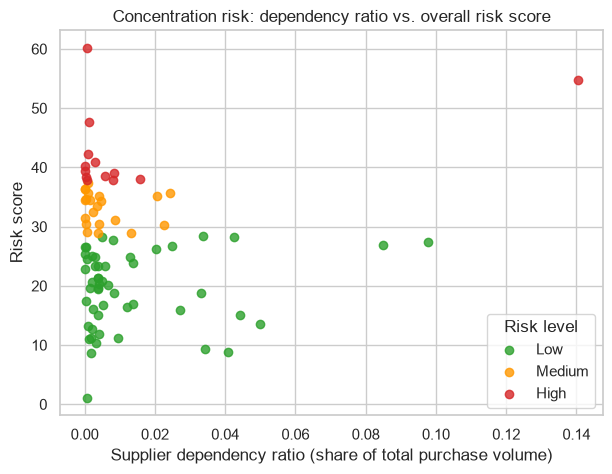

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for level in RISK_ORDER:
    subset = scores_df[scores_df["risk_level"] == level]
    ax.scatter(subset["supplier_dependency_ratio"], subset["risk_score"],
               color=RISK_COLORS[level], label=level, alpha=0.8)
ax.set_xlabel("Supplier dependency ratio (share of total purchase volume)")
ax.set_ylabel("Risk score")
ax.set_title("Concentration risk: dependency ratio vs. overall risk score")
ax.legend(title="Risk level")
plt.show()

## 5. v2: Financial risk axis, portfolio concentration, and due-diligence red flags

Everything in this section is deliberately **not blended** into `risk_score` above — see `compute_financial_risk_score`'s docstring in `src/score_suppliers.py` for why. A supplier can be operationally excellent but financially fragile, or vice versa, and merging both into one number would hide which kind of risk is actually driving a rating. Real commercial platforms (e.g. SAP Ariba) keep financial, compliance, and sustainability risk as separate facets for the same reason.

**`financial_risk_score`** (0-100, higher = riskier) is a second, independent axis built from three financial/solvency signals — overdue debt ratio (30%), debt-to-revenue leverage (30%), and a payment-default-in-last-3-years flag (40%) — conceptually inspired by what a real **Findeks Ticari Risk Raporu** (Turkey's actual commercial credit bureau product) covers. It is *not* a reproduction of KKB's actual proprietary scoring formula, which isn't publicly published.

**Portfolio HHI** (Herfindahl-Hirschman Index) is a real, standard economics concentration metric — the sum of each supplier's squared share of total spend, scaled to the conventional 0-10,000 range, using the same DOJ antitrust-review thresholds (<1,500 low, 1,500-2,500 moderate, >2,500 high concentration).

**Red flags** (`has_export_documentation`, `requires_full_upfront_payment`, `site_visit_verified`) are qualitative, practitioner-grounded due-diligence signals — not derived from a formula, but from concrete criteria a real Turkish sourcing consultant described using to vet suppliers in practice.

Portfolio concentration (HHI): 531 / 10,000 (low concentration)



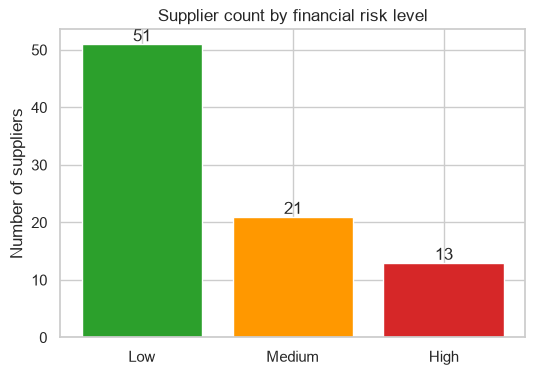

In [12]:
from score_suppliers import compute_portfolio_hhi

portfolio_hhi = compute_portfolio_hhi(scores_df["supplier_dependency_ratio"])
hhi_level = "low" if portfolio_hhi < 1_500 else "moderate" if portfolio_hhi < 2_500 else "high"
print(f"Portfolio concentration (HHI): {portfolio_hhi:.0f} / 10,000 ({hhi_level} concentration)")
print()

fin_counts = scores_df["financial_risk_level"].value_counts().reindex(RISK_ORDER)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(fin_counts.index, fin_counts.values, color=[RISK_COLORS[level] for level in RISK_ORDER])
ax.set_title("Supplier count by financial risk level")
ax.set_ylabel("Number of suppliers")
for i, v in enumerate(fin_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.show()

Overlap between top-10 operationally-riskiest and top-10 financially-riskiest suppliers: 2 / 10


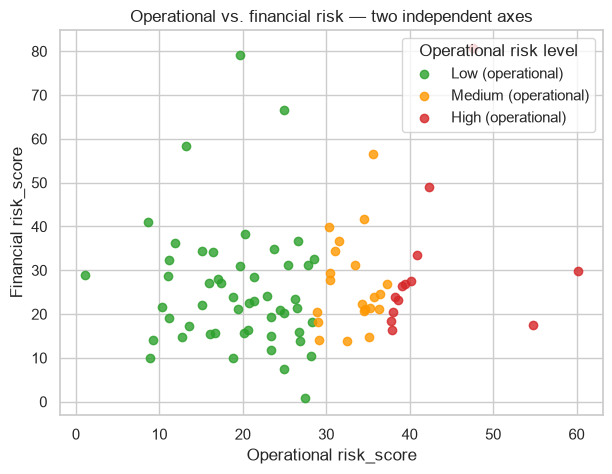

In [13]:
# The whole point of keeping the two axes separate: are they actually telling
# a different story, or is financial_risk_score just a re-scaled copy of risk_score?
top10_operational = set(scores_df.sort_values("risk_score", ascending=False).head(10)["company_name"])
top10_financial = set(scores_df.sort_values("financial_risk_score", ascending=False).head(10)["company_name"])
overlap = top10_operational & top10_financial
print(f"Overlap between top-10 operationally-riskiest and top-10 financially-riskiest suppliers: {len(overlap)} / 10")

fig, ax = plt.subplots(figsize=(7, 5))
for level in RISK_ORDER:
    subset = scores_df[scores_df["risk_level"] == level]
    ax.scatter(subset["risk_score"], subset["financial_risk_score"],
               color=RISK_COLORS[level], label=f"{level} (operational)", alpha=0.8)
ax.set_xlabel("Operational risk_score")
ax.set_ylabel("Financial risk_score")
ax.set_title("Operational vs. financial risk — two independent axes")
ax.legend(title="Operational risk level")
plt.show()

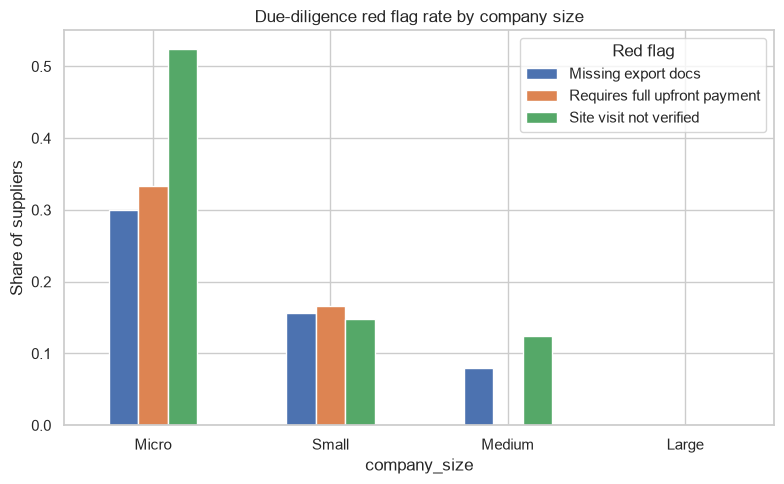

In [14]:
# Red flags live in the cleaned dataset (clean_df), not the scored output —
# they're qualitative due-diligence signals, not inputs to either risk score.
# A handful of rows have a missing (NaN) flag value (simulated messy-export
# data); cast to pandas' nullable boolean dtype so those are skipped by
# .mean() rather than crashing the invert operator.
export_docs = clean_df["has_export_documentation"].astype("boolean")
upfront_payment = clean_df["requires_full_upfront_payment"].astype("boolean")
site_visit = clean_df["site_visit_verified"].astype("boolean")
size_order_4tier = ["Micro", "Small", "Medium", "Large"]

# For "requires_full_upfront_payment", True is the red flag; for the other two, False is.
red_flag_rate = pd.DataFrame({
    "Missing export docs": (~export_docs).groupby(clean_df["company_size"]).mean(),
    "Requires full upfront payment": upfront_payment.groupby(clean_df["company_size"]).mean(),
    "Site visit not verified": (~site_visit).groupby(clean_df["company_size"]).mean(),
}).astype(float).reindex(size_order_4tier)

ax = red_flag_rate.plot(kind="bar", figsize=(8, 5))
ax.set_title("Due-diligence red flag rate by company size")
ax.set_ylabel("Share of suppliers")
ax.legend(title="Red flag")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Weight sensitivity (bonus)

The scoring weights are a business decision, not a fixed fact — so it's worth checking how much the ranking actually changes if priorities shift. Below, the same cleaned data is re-scored under three weight profiles using the exact same `compute_metrics` / `compute_risk_score` functions from `src/score_suppliers.py` (proving the pipeline is genuinely reusable, not just a one-off script).

In [15]:
from score_suppliers import compute_metrics, compute_risk_score

metrics_df = compute_metrics(clean_df)

scenarios = {
    "Default (delivery-focused)": {
        "delivery_delay_rate": 0.35, "price_volatility": 0.25,
        "supplier_dependency_ratio": 0.25, "quality_return_rate": 0.15,
    },
    "Cost-focused": {
        "delivery_delay_rate": 0.15, "price_volatility": 0.45,
        "supplier_dependency_ratio": 0.25, "quality_return_rate": 0.15,
    },
    "Quality-focused": {
        "delivery_delay_rate": 0.20, "price_volatility": 0.15,
        "supplier_dependency_ratio": 0.15, "quality_return_rate": 0.50,
    },
}

comparison = pd.DataFrame({"company_name": metrics_df["company_name"]})
for name, weights in scenarios.items():
    config = {"weights": weights, "risk_level_thresholds": {"low_percentile": 0.60, "high_percentile": 0.85}}
    scored = compute_risk_score(metrics_df, config)
    comparison[name] = scored["risk_score"]

comparison.sort_values("Default (delivery-focused)", ascending=False).head(8)

,company_name,Default (delivery-focused),Cost-focused,Quality-focused
33,Hançer Gülen Mobilya Tic.,60.2,48.3,76.1
51,Aksu San. ve Tic. A.Ş.,54.8,48.8,35.9
80,Arslan Çorlu Kauçuk Tic.,47.6,37.4,31.4
44,Şener Mansız Otomotiv Tic.,42.3,40.9,32.9
26,Yıldırım Otomotiv Ltd. Şti.,40.9,23.3,34.6
42,Ülker Mobilya Tic.,40.2,27.1,30.4
75,Sakarya Kisakürek İplik Ltd. Şti.,39.4,34.5,24.4
22,Çorlu İnönü Lojistik San. ve Tic. A.Ş.,39.1,36.7,24.6


## Key takeaways

- Of 85 synthetic suppliers, the operational-risk pipeline flags roughly the riskiest ~15% as **High** and the safest ~60% as **Low**, using percentile-based cutoffs so the labels stay meaningful regardless of how the underlying scores are distributed.
- The single highest-risk supplier is high-risk mainly because of **concentration risk**: its `supplier_dependency_ratio_score` is close to 100/100 under the HHI-inspired squared-share normalization — a concrete, explainable driver, not a black box.
- **Operational and financial risk are genuinely different dimensions**, not two views of the same thing: the top-10 operationally-riskiest and top-10 financially-riskiest suppliers overlap only partially, confirming that blending them into one score would have hidden which kind of risk actually applies to a given supplier.
- **Portfolio concentration (HHI)** is computed from the same underlying spend shares as a portfolio-level summary stat, independent of any single supplier's score — a real economics/antitrust metric applied to procurement.
- **Due-diligence red flags** (missing export documentation, demanding full upfront payment, no verified site visit) are markedly more common among Micro suppliers than Large ones — consistent with the size-tiered generation logic, and a concrete example of a qualitative signal that a purely numeric scorecard would miss.
- Scoring weights are configurable (`config/scoring_weights.yaml`), and re-running the same scoring functions under different weight profiles shows the ranking is genuinely sensitive to business priorities — e.g. a cost-focused company would flag a different top-risk supplier than a delivery-focused one.
- Cleaning decisions were made explicitly and conservatively, via a profile-driven engine that has zero knowledge of *this specific* dataset: structured fields (sector, city, category labels, VKN tax IDs) were fully recovered/validated via canonical matching and a real checksum algorithm, while free-text fields with already-lost information (company name diacritics) were left as-is rather than guessed — an intentional, documented data-quality boundary.